<a href="https://colab.research.google.com/github/AhmadSyahreza/Katanya-kami-lomba/blob/main/Awal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Katanya Kami Lomba

Notebook ini digunakan untuk coding dan analisis data.

In [16]:
!pip install pandas numpy matplotlib seaborn

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
train1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/train.csv')
test1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/test.csv')
holidays = pd.read_csv('/content/drive/MyDrive/Lomba Data/holidays.csv')
movies = pd.read_csv('/content/drive/MyDrive/Lomba Data/movies.csv')
ticket_prices = pd.read_csv('/content/drive/MyDrive/Lomba Data/ticket_prices.csv')
test_history = pd.read_csv('/content/drive/MyDrive/Lomba Data/test_history.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/Lomba Data/sample_submission.csv')

In [20]:
holidays

,date,day_tipe,holiday_tipe,holiday_name
0,2025-04-01,weekday,holiday,Idulfitri 1446 H
1,2025-04-02,weekday,normal,NaN
2,2025-04-03,weekday,normal,NaN
3,2025-04-04,friday,normal,NaN
4,2025-04-05,weekend,normal,NaN
...,...,...,...,...
361,2026-03-28,weekend,normal,NaN
362,2026-03-29,weekend,normal,NaN
363,2026-03-30,weekday,normal,NaN
364,2026-03-31,weekday,normal,NaN


In [21]:
movies

,original_title,age_rating,genre,producer,director,writer,casts
0,120 BAHADUR,Remaja,"Action, War","Farhan Akhtar, Amit Chandrra, Ritesh Sidhwani",Razneesh Ghai,Sumit Arora,"Ankit Siwach, Farhan Akhtar, Amitabh Bachchan,..."
1,"13 DAYS, 13 NIGHTS",Remaja,"Action, War","Dimitri Rassam, Ardavan Safaee",Martin Bourboulon,"Martin Bourboulon, Alexandre Smia, Mohamed Bid...","Roschdy Zem, Lyna Khoudri, Sidse Babett Knudse..."
2,28 YEARS LATER,Dewasa,Thriller,"Danny Boyle, Alex Garland, Peter Rice",Danny Boyle,"Danny Boyle, Alex Garland","Jodie Comer, Aaron Taylor-Johnson, Jack O'Conn..."
3,28 YEARS LATER: THE BONE TEMPLE,Dewasa,Thriller,"Danny Boyle, Alex Garland, Andrew Macdonald",Nia DaCosta,Alex Garland,"Ralph Fiennes, Alfie Williams, Jack O'Connell,..."
4,5 CENTIMETERS PER SECOND (ANIMATION),Remaja,Animation,"Makoto Shinkai, Jin Ho Chung",Makoto Shinkai,Makoto Shinkai,"Kenji Mizuhashi, Yoshimi Kondou, Satomi Hanamu..."
...,...,...,...,...,...,...,...
392,WUTHERING HEIGHTS,Dewasa,"Romance, Drama","Emerald Fennell, Josey McNamara, Margot Robbie",Emerald Fennell,"Emerald Fennell, Emily Bronte","Margot Robbie, Jacob Elordi, Hong Chau, Shazad..."
393,YAKIN NIKAH,Remaja,"Drama, Romance","Shierly Kosasih, Ervina Isleyen",Pritagita Arianegara,"Bene Dion Rajagukguk, Sigit Sulistyo, Erwin Wu","Enzy Storia, Maxime Bouttier, Jourdy Pranata, ..."
394,YOU ARE THE APPLE OF MY EYE,Remaja,"Drama, Romance",Song Dae-chan,Cho Young-myoung,"Giddens Ko, Cho Young-myoung","Jung Jin-young, Kim Da-hyun, Demian, Kim Yo-ha..."
395,YOUR LETTER,Semua Umur,Animation,-,Kim Yong-hwan,Jeong Eun-kyeong,"Lee Suhyun, Kim Min-ju, Min Seung-woo, Nam Doh..."


In [22]:

for df in [train1, test1, test_history]:
    df["date_show"] = pd.to_datetime(df["date_show"])
holidays["date"] = pd.to_datetime(holidays["date"])

print("Train shape :", train1.shape)
print("Test shape  :", test1.shape)
print("Train       :", train1["date_show"].min().date(), "sampai", train1["date_show"].max().date())
print("Test        :", test1["date_show"].min().date(), "sampai", test1["date_show"].max().date())

Train shape : (138959, 7)
Test shape  : (72611, 5)
Train       : 2025-04-01 sampai 2025-09-30
Test        : 2025-10-04 sampai 2026-03-27


In [23]:
train1.isnull().sum().to_frame("Total Missing value ")

,Total Missing value
date_show,0
cinema_ids,0
city_name,0
movie_title,0
total_ticket,0
occupation_rate,0
total_show,0


In [24]:
train1[["total_ticket", "occupation_rate", "total_show"]].describe().round(2)

,total_ticket,occupation_rate,total_show
count,138959.00,138959.00,138959.00
mean,354.12,28.33,7.73
std,725.93,22.62,11.01
min,1.00,0.00,1.00
25%,69.00,12.36,3.00
50%,161.00,21.84,5.00
75%,361.00,37.01,8.00
max,32845.00,100.00,285.00


                 total_ticket  occupation_rate  total_show
total_ticket            1.000            0.309       0.786
occupation_rate         0.309            1.000       0.004
total_show              0.786            0.004       1.000


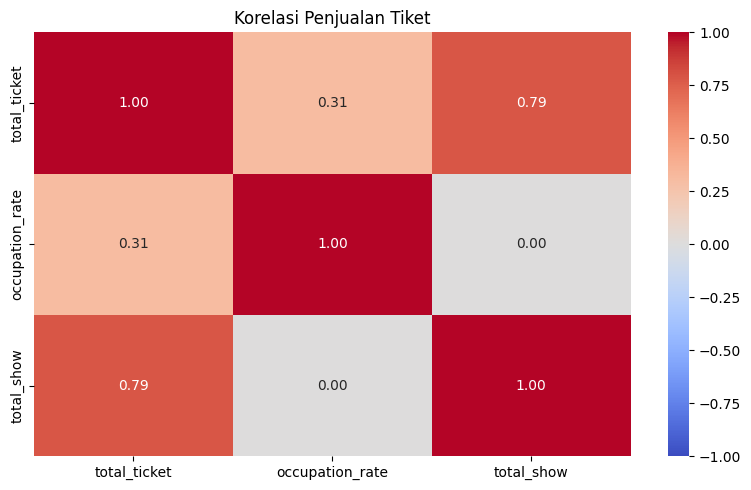

In [25]:
num_cols = [
    "total_ticket",
    "occupation_rate",
    "total_show"
]

corr = train1[num_cols].corr(method="pearson")

print(corr.round(3))

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Korelasi Penjualan Tiket")
plt.tight_layout()
plt.show()

In [26]:
film_test = set(test1['movie_title'])
film_movies = set(movies['original_title'])
film_missing = film_test - film_movies
kota_test = set(test1['city_name'])
kota_prices = set(ticket_prices['city_name'])
kota_missing = kota_test - kota_prices

summary_data = {
    "Kategori Pengecekan": ["Judul Film", "Nama Kota"],
    "Total Unik": [len(film_test), len(kota_test)],
    "Ada": [len(film_test - film_missing), len(kota_test - kota_missing)],
    "Missing": [len(film_missing), len(kota_missing)],
    "Status": [
        " film belum terdaftar" if len(film_missing) > 0 else "",
        " kota belum terdaftar" if len(kota_missing) > 0 else ""
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Kategori Pengecekan,Total Unik,Ada,Missing,Status
0,Judul Film,160,140,20,film belum terdaftar
1,Nama Kota,69,69,0,


In [27]:
df_missing_movies = pd.DataFrame({
    "Judul Missing": sorted((film_missing))
})

display(df_missing_movies)

,Judul Missing
0,AVATAR: FIRE AND ASH (3D)
1,AVATAR: FIRE AND ASH (IMAX 3D)
2,BLADES OF THE GUARDIANS (IMAX 2D)
3,DANUR: THE LAST CHAPTER (IMAX 2D)
4,EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)
5,HOPPERS (3D)
6,HOPPERS (IMAX 2D)
7,MERCY (IMAX 2D)
8,PREDATOR: BADLANDS (3D)
9,PREDATOR: BADLANDS (IMAX 2D)


In [28]:
def find_d1(df):
    nat = df.groupby(['movie_title','date_show'])['total_ticket'].sum().reset_index()
    first = nat.groupby('movie_title')['date_show'].min()
    out = {}
    for m, g in nat.groupby('movie_title'):
        ds = set(g['date_show'])
        for d in sorted(ds):
            if {d + pd.Timedelta(days=1), d + pd.Timedelta(days=2)} <= ds:
                out[m] = d
                break
    f = pd.Series(out, name='D1').rename_axis('movie_title').reset_index()
    f['first_date'] = f['movie_title'].map(first)
    return f

f = find_d1(train1)
tmin, tmax = train1['date_show'].min(), train1['date_show'].max()
f = f[(f['D1'] > tmin + pd.Timedelta(days=2)) &
      (f['D1'] + pd.Timedelta(days=9) <= tmax) &
      ((f['D1'] - f['first_date']).dt.days <= 3)].reset_index(drop=True)

print("jumlah film :", len(f), "dari", train1['movie_title'].nunique())
f.head()

jumlah film : 108 dari 237


,movie_title,D1,first_date
0,28 YEARS LATER,2025-06-17,2025-06-17
1,A BIG BOLD BEAUTIFUL JOURNEY,2025-09-18,2025-09-18
2,A MINECRAFT MOVIE,2025-04-04,2025-04-04
3,A MINECRAFT MOVIE (3D),2025-04-09,2025-04-09
4,A MINECRAFT MOVIE (IMAX 2D),2025-04-08,2025-04-08


# **WINDOW**

Ini aku pakai window karena dari task paling utamanya diminta :
- data hari 1-3 terhadap minggu depannya
- berarti dalam 1 hari itu semua pertunjukan dan tiketnya seberapa ngaruh ke minggu depannya

In [36]:
def build_windows(df): #DF nya dataset Train
    windows = []

    for (film, bioskop), group in df.groupby(['movie_title', 'cinema_ids']):
        group = group.sort_values('date_show').reset_index(drop=True)
        for start in range(len(group)):
            window = group.iloc[start:start+10] #Harusnya disini eror kalau ak ambil Y=iloc[6:9] [AWAL]
            if len(window) < 10:
                continue
            if (window['date_show'].diff()[1:] != pd.Timedelta(days=1)).any():
                continue

            X_window = window.iloc[0:3] #ini data dimana kita tarik hari(1-3) [FIX]
            Y_window = window.iloc[3:10] #Ini aku pakai default (01.52
           #Aku ganti ini we ke targetnya hari(1-4) tapi di minggu depannya (01.30) [EROR]
           #kode aslinya ini hari(4-10) [AWAL]
            windows.append({
                'cinema_ids': bioskop,
                'movie_title': film,
                'city_name': X_window.iloc[0]['city_name'],
                'date_D1': X_window.iloc[0]['date_show'],
                'd1': X_window.iloc[0]['total_ticket'],
                'd2': X_window.iloc[1]['total_ticket'],
                'd3': X_window.iloc[2]['total_ticket'],
                'target_4': Y_window.iloc[0]['total_ticket'],
                'target_5': Y_window.iloc[1]['total_ticket'],
                'target_6': Y_window.iloc[2]["total_ticket"],
                'target_7': Y_window.iloc[3]["total_ticket"],
                'target_8': Y_window.iloc[4]["total_ticket"],
                'target_9': Y_window.iloc[5]["total_ticket"],
                'target_10': Y_window.iloc[6]["total_ticket"]
                })

    return pd.DataFrame(windows)

# **DIBAWAH INI OPSIONAL (DATA SET PEMBANTU)**

In [30]:
X_df = build_windows(train1)
n_awal = len(X_df)
print(X_df.shape)

(48466, 14)


# **Merge movies & ticket_prices**

In [31]:
movies_u = movies.drop_duplicates("original_title")
X_df = X_df.merge(movies_u, left_on="movie_title", right_on="original_title", how="left")  #dari movies.csv
prices_num = ticket_prices.groupby("city_name", as_index=False).mean(numeric_only=True)
X_df = X_df.merge(prices_num, on="city_name", how="left") #Dari ticket_prices.csv
#Weekday/weekend/holiday

# Merge holidays

In [32]:
holidays['date'] = pd.to_datetime(holidays['date'])
holidays_u = holidays.drop_duplicates("date")
X_df = X_df.merge(holidays_u, left_on="date_D1", right_on="date", how="left") #Ibarat mySQL join target day
#ini bisa nambahin kolom kategori/mapping kalau mau we

# Fitur tambahan


In [33]:
X_df["avg_d1_d3"] = X_df[["d1", "d2", "d3"]].mean(axis=1)
X_df["dow_d1"] = X_df["date_D1"].dt.dayofweek
X_df["month_d1"] = X_df["date_D1"].dt.month
X_df["target_start_date"] = X_df["date_D1"] + pd.Timedelta(days=3)  # tanggal D4

# **BAGI DATANYA JADI 3**
TRAIN
VALIDASI
TEST

**Untuk semua data train gunain 2/3 utk kt train dan 1/3 utk validasi**

In [37]:
train_mask = X_df["target_start_date"] < pd.Timestamp("2026-01-01")
if train_mask.sum() == 0 or (~train_mask).sum() == 0:
    cutoff = X_df["target_start_date"].quantile(0.8)
    train_mask = X_df["target_start_date"] < cutoff
    print("Cutoff diganti ke:", cutoff.date())

print("Train:", train_mask.sum(), "| Valid:", (~train_mask).sum())

# Y = hanya kolom target
Y_train = X_df.loc[train_mask, target_cols]
Y_valid = X_df.loc[~train_mask, target_cols]

# X = tanpa target, tanpa kolom tanggal
X_all = X_df.drop(columns=target_cols + ["target_start_date"])
X_all = X_all.drop(columns=X_all.select_dtypes(include="datetime64[ns]").columns)
X_all["cinema_ids"] = X_all["cinema_ids"].astype(str)

# Pisahkan kolom kategori & numerik
id_cols = ["movie_title", "original_title"]
obj_cols = [c for c in X_all.select_dtypes(exclude=np.number).columns if c not in id_cols]
cat_cols = [c for c in obj_cols if X_all[c].nunique() <= 100]   # buang teks panjang
num_cols_m = X_all.select_dtypes(include=np.number).columns.tolist()
X_all[cat_cols] = X_all[cat_cols].astype(str)

print("Kategori :", cat_cols)
print("Numerik  :", num_cols_m)

X_train = X_all.loc[train_mask]
X_valid = X_all.loc[~train_mask] #Ini negasinya

#[Valid] = NEGASI dari [Train]

Cutoff diganti ke: 2025-08-23
Train: 38388 | Valid: 10078
Kategori : ['city_name', 'age_rating', 'genre', 'day_tipe', 'holiday_tipe', 'holiday_name']
Numerik  : ['d1', 'd2', 'd3', 'ceil', 'avg_d1_d3', 'dow_d1', 'month_d1']


# **import**

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

target_cols = [f"target_{i}" for i in range(4, 11)]

# Model baseline

In [ ]:
avg_valid = X_df.loc[~train_mask, "avg_d1_d3"].values[:, None]
Y_pred_naive = np.repeat(avg_valid, len(target_cols), axis=1)
print("MAE (Naive) :", round(mean_absolute_error(Y_valid, Y_pred_naive), 3))

preprocess = ColumnTransformer([
    ("cat", make_pipeline(
        SimpleImputer(strategy="constant", fill_value="unknown"),
        OneHotEncoder(handle_unknown="ignore", min_frequency=5)
    ), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols_m),
])
X_train_encoded = preprocess.fit_transform(X_train[cat_cols + num_cols_m])
X_valid_encoded = preprocess.transform(X_valid[cat_cols + num_cols_m])

lr = MultiOutputRegressor(LinearRegression())
lr.fit(X_train_encoded, Y_train)
Y_pred_lr = np.clip(lr.predict(X_valid_encoded), 0, None)
print("MAE (Linear):", round(mean_absolute_error(Y_valid, Y_pred_lr), 3))

# Catboost


In [ ]:
!pip install catboost -q
from catboost import CatBoostRegressor

X_train_cb = X_train[cat_cols + num_cols_m].copy()
X_valid_cb = X_valid[cat_cols + num_cols_m].copy()
X_train_cb[cat_cols] = X_train_cb[cat_cols].fillna("unknown")
X_valid_cb[cat_cols] = X_valid_cb[cat_cols].fillna("unknown")

cat = MultiOutputRegressor(
    CatBoostRegressor(
        iterations=500, learning_rate=0.1, depth=6,
        loss_function="MAE", verbose=0, random_seed=42,
        cat_features=cat_cols
    )
)
cat.fit(X_train_cb, Y_train)
Y_pred_cat = np.clip(cat.predict(X_valid_cb), 0, None)

hasil["CatBoost"] = mean_absolute_scaled_error(Y_valid, Y_pred_cat, scale_valid)
print(f"MAE  CatBoost: {mean_absolute_error(Y_valid, Y_pred_cat):.3f}")
print(f"MASE CatBoost: {hasil['CatBoost']:.4f}")

# **DIBAWAH INI RUMUS MASE**

In [39]:
from sklearn.metrics import mean_absolute_error

def hitung_skala(history):
    """
    history: tiga hari observasi (D1-D3) untuk tiap pasangan klaster-film
    """
    total = history.groupby(["movie_title", "cinema_ids"]).total_ticket.sum()
    return (total / 3).clip(lower=1).rename("scale")

scale = target.join(hitung_skala(history), on=["movie_title", "cinema_ids"]).scale
skor = mean_absolute_scaled_error(y_true, y_pred, scale)

def mean_absolute_scaled_error(y_true, y_pred, scale):
    """
    y_true: jumlah tiket terjual
    y_pred: forecast tiket terjual
    scale: rata-rata tiket terjual di tiga hari pertama
    """
    return mean_absolute_error(y_true / scale, y_pred / scale) #ALHAMDULILLAH UDAH PAS

scale = target.join(hitung_skala(history), on=["movie_title", "cinema_ids"]).scale
skor = mean_absolute_scaled_error(y_true, y_pred, scale)


NameError: name 'target' is not defined

In [40]:
def hitung_scale(avg_d1_d3):
    """scale = rata-rata tiket D1-D3 per film-bioskop, minimal 1"""
    return np.clip(np.asarray(avg_d1_d3, float), 1, None)[:, None]

def mean_absolute_scaled_error(y_true, y_pred, scale):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return np.mean(np.abs(y_true / scale - y_pred / scale))

scale_valid = hitung_scale(X_df.loc[~train_mask, "avg_d1_d3"])

hasil = {}
hasil["Naive"]  = mean_absolute_scaled_error(Y_valid, Y_pred_naive, scale_valid)
hasil["Linear"] = mean_absolute_scaled_error(Y_valid, Y_pred_lr, scale_valid)

for k, v in hasil.items():
    print(f"MASE {k:<8}: {v:.4f}")

NameError: name 'Y_pred_naive' is not defined

## **CEKKK LAGII JANGAN LUPAA**

In [41]:
import lightgbm as lgb

X_train_lgb = X_train[cat_cols + num_cols_m].copy()
X_valid_lgb = X_valid[cat_cols + num_cols_m].copy()

cat_levels = {}
for c in cat_cols:
    cat_levels[c] = pd.Categorical(X_train_lgb[c]).categories
    X_train_lgb[c] = pd.Categorical(X_train_lgb[c], categories=cat_levels[c])
    X_valid_lgb[c] = pd.Categorical(X_valid_lgb[c], categories=cat_levels[c])

params = {
    'objective': 'regression',
    'metric': 'l2',  # gunakan MSE untuk internal monitoring
    'learning_rate': 0.05,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'seed': 42
}
lgb_models = {}
Y_pred_lgb = np.zeros((len(X_valid_lgb), len(target_cols)))

for j, t in enumerate(target_cols):
    dtr = lgb.Dataset(X_train_lgb, Y_train[t])
    dva = lgb.Dataset(X_valid_lgb, Y_valid[t], reference=dtr)
    m = lgb.train(
        params, dtr, num_boost_round=1000,
        valid_sets=[dva],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    lgb_models[t] = m
    Y_pred_lgb[:, j] = m.predict(X_valid_lgb, num_iteration=m.best_iteration)
Y_pred_lgb = np.clip(Y_pred_lgb, 0, None)
hasil["LightGBM"] = mean_absolute_scaled_error(Y_valid, Y_pred_lgb, scale_valid)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005353 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 38388, number of used features: 13
[LightGBM] [Info] Start training from score 657.851907
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035152 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train set: 38388, number of used features: 13
[LightGBM] [Info] Start training from score 605.784334
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1183
[LightGBM] [Info] Number of data points in the train

# **JANGAN LUPA CEK**

In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(Y_valid, Y_pred))
print("RMSE:", mean_squared_error(Y_valid, Y_pred, squared=False))
print("R2:", r2_score(Y_valid, Y_pred))

NameError: name 'Y_pred' is not defined

In [43]:
print(test1.columns.tolist())
print(test_history.columns.tolist())
print(sample_submission.head())
print(test1.head(3))

['id', 'movie_title', 'cinema_ids', 'city_name', 'date_show']
['date_show', 'cinema_ids', 'city_name', 'movie_title', 'total_ticket', 'occupation_rate', 'total_show']
   id  total_ticket
0   1         100.0
1   2         100.0
2   3         100.0
3   4         100.0
4   5         100.0
   id         movie_title                        cinema_ids city_name  \
0   1  13 DAYS, 13 NIGHTS  015555fbcd8faef6b55a854605df0a87  SURABAYA   
1   2  13 DAYS, 13 NIGHTS  015555fbcd8faef6b55a854605df0a87  SURABAYA   
2   3  13 DAYS, 13 NIGHTS  015555fbcd8faef6b55a854605df0a87  SURABAYA   

   date_show  
0 2025-12-08  
1 2025-12-09  
2 2025-12-10  


# **INI UTK SUBMISSION**

In [44]:
X_test = merge_supporting_features(test_df) # Merge fitur di test set sama seperti train
pred_test = model.predict(X_test)  # output shape (n_test, ) #Ini prediksi
# Clip nilai negatif jadi 0
pred_test = np.clip(pred_test, 0, None)

# Susun DataFrame submission
submission = pd.DataFrame({
    'id': test_df['id'],
    'total_ticket': pred_test #Ini udah cocok sama apa yang di minta
})
submission.to_csv("submission.csv", index=False)
print(submission.head())

NameError: name 'merge_supporting_features' is not defined

# **KORELASI KORELASI GRAFIK **

Malam ni tidur besok re check ke **claude**

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("/content/drive/MyDrive/Lomba Data/train.csv")
test = pd.read_csv("/content/drive/MyDrive/Lomba Data/test.csv")
history = pd.read_csv("/content/drive/MyDrive/Lomba Data/test_history.csv")

#da ku cocokkan ini ama data" yg di atas
train["date_show"] = pd.to_datetime(train["date_show"])
print(train.shape)
print(train.head())
print()
print()
print(train.info())

(138959, 7)
   date_show                        cinema_ids city_name  \
0 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
1 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
2 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
3 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   
4 2025-04-01  015555fbcd8faef6b55a854605df0a87  SURABAYA   

                        movie_title  total_ticket  occupation_rate  total_show  
0                     A WORKING MAN           487            31.07          18  
1                             JUMBO           649            23.69          19  
2                            KOMANG           389             9.55          22  
3                          NE ZHA 2           101            70.03           3  
4  NORMA: ANTARA MERTUA DAN MENANTU           411            17.76          13  


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138959 entries, 0 to 138958
Data columns (total 7 columns):
 #   Column           Non-Nul

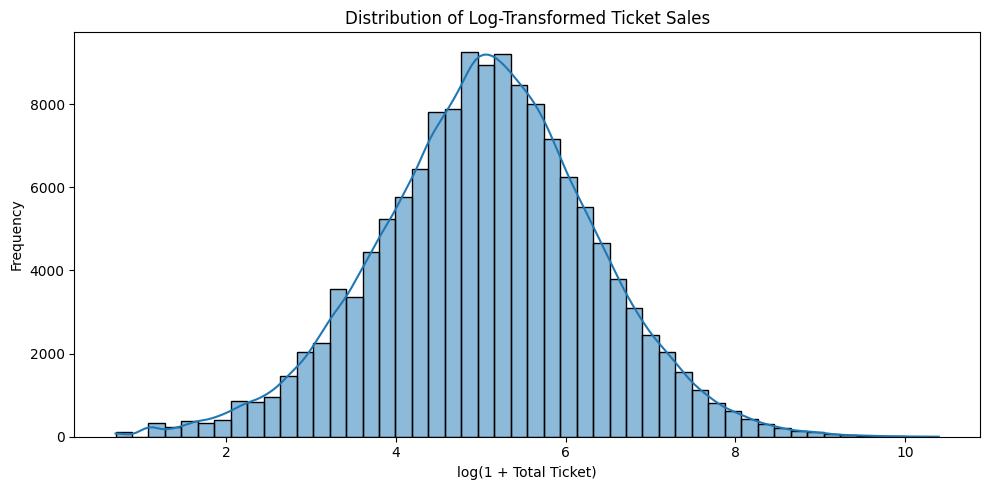

In [47]:
plt.figure(figsize=(10, 5))

sns.histplot(
    np.log1p(train["total_ticket"].clip(lower=0)),
    bins=50,
    kde=True
)

plt.title("Distribution of Log-Transformed Ticket Sales")
plt.xlabel("log(1 + Total Ticket)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ALHAMDULILLAH PAS GRAFIKNYA

In [48]:
#AWAK BIKIN PERMINGGU
daily_sales["rolling_7d"] = (
    daily_sales["total_ticket"]
    .rolling(7, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date_show"],
    daily_sales["total_ticket"],
    alpha=0.35,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date_show"],
    daily_sales["rolling_7d"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Daily Ticket Sales with 7-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Total Tickets")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

NameError: name 'daily_sales' is not defined

Grafiknya turun drastis ya. hmz
- oke good, ga lari banget


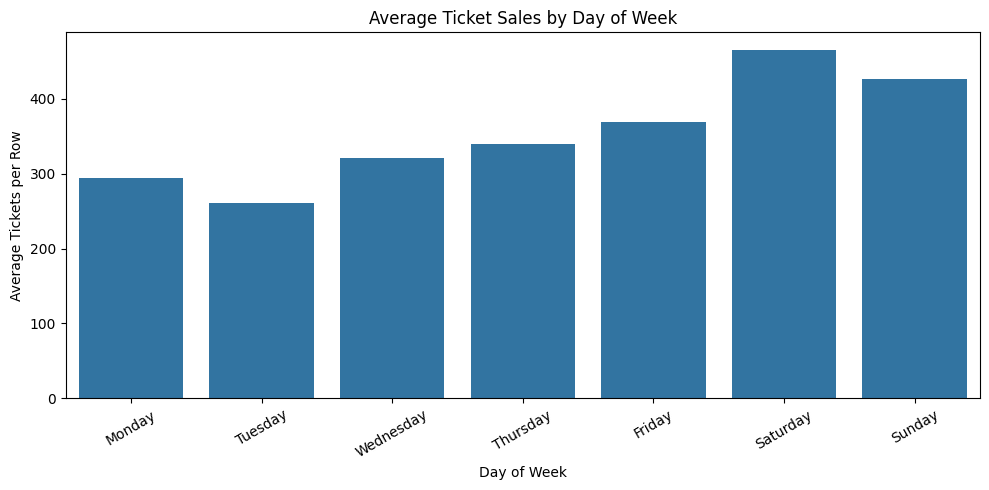

In [49]:
train["day_of_week"] = train["date_show"].dt.dayofweek

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

train["day_name"] = train["day_of_week"].map(day_names)

weekday_sales = (
    train.groupby("day_name")["total_ticket"]
    .mean()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title("Average Ticket Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Tickets per Row")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Memang sabtu minggu itu terbaik buat nonton we, aplagi pacaran

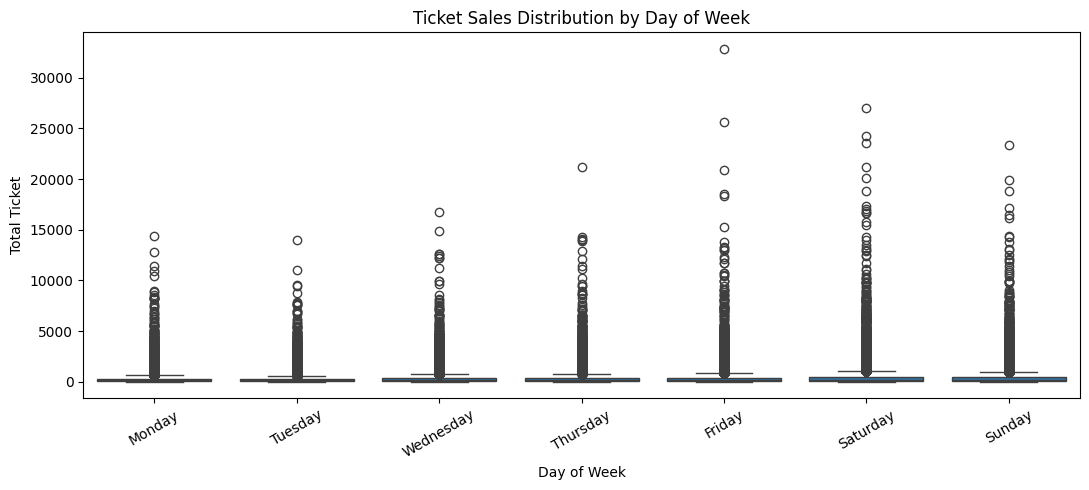

In [50]:
plt.figure(figsize=(11, 5)) #Ini kalau pakai semua datanya ya soalnya ini perbandingan ama distribusi

sns.boxplot(
    data=train,
    x="day_name",
    y="total_ticket",
    order=[
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ]
)

plt.title("Ticket Sales Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Total Ticket")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Karena sabtu itu mula libur org pulang ngantor nonton langsung keknya pas hari jumat

## **DIBAWAH INI BINTANGNYA**

In [51]:
# windows adalah DataFrame hasil sliding window
target_cols = [
    f"target_{i}" for i in range(4, 11)
]

windows["avg_d1_d3"] = windows[ #Window hari(1-3)
    ["d1", "d2", "d3"]
].mean(axis=1)

windows["avg_d4_d10"] = windows[ #Window Hari(4-10)
    target_cols
].mean(axis=1)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=windows,
    x="avg_d1_d3",
    y="avg_d4_d10",
    alpha=0.4
)

plt.title("Initial Sales vs Future Ticket Sales")
plt.xlabel("Average Tickets D1-D3")
plt.ylabel("Average Tickets D4-D10")

plt.tight_layout()
plt.show()

NameError: name 'windows' is not defined

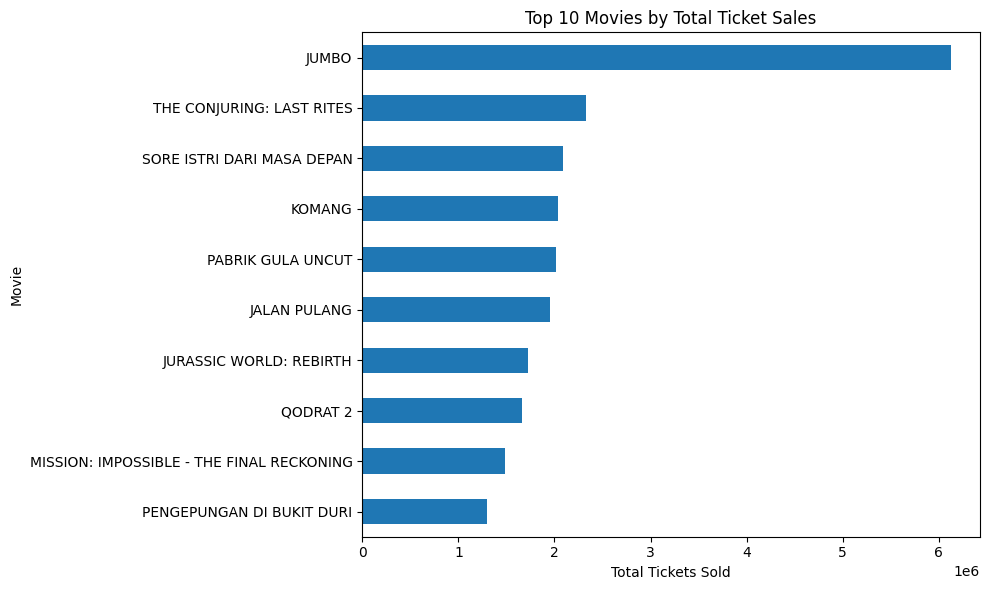

In [52]:
top_movies = (
    train.groupby("movie_title")["total_ticket"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))

top_movies.plot(kind="barh")

plt.title("Top 10 Movies by Total Ticket Sales")
plt.xlabel("Total Tickets Sold")
plt.ylabel("Movie")

plt.tight_layout()
plt.show()

In [53]:
price_col = "ticket_price"

price_city = prices[
    ["city_name", price_col]
].drop_duplicates()

price_sales = train.merge(
    price_city,
    on="city_name",
    how="left"
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=price_sales,
    x=price_col,
    y="total_ticket",
    alpha=0.4
)

plt.title("Ticket Price vs Ticket Sales")
plt.xlabel("Ticket Price")
plt.ylabel("Total Tickets")

plt.tight_layout()
plt.show()

NameError: name 'prices' is not defined

PENYELESAIAN AKHIR DIBAWAH INI
- kenapa akhir?
karena ini membandingkna hasil train X validasi kita

tabel dibawah ini tabel actual vs predict

In [ ]:
sample_idx = 0

days = list(range(4, 11))

plt.figure(figsize=(9, 5))

plt.plot(
    days,
    np.array(Y_valid)[sample_idx],
    marker="o",
    label="Actual"
)

plt.plot(
    days,
    np.array(Y_pred)[sample_idx],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted: D4-D10")
plt.xlabel("Forecast Day")
plt.ylabel("Total Tickets")
plt.xticks(days)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()